In [1]:
import os
import matplotlib.pyplot as plt
import torch
import alpha_clip
from PIL import Image
import numpy as np
from torchvision import transforms

In [17]:
# load model and prepare mask transform
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = alpha_clip.load("ViT-B/16", alpha_vision_ckpt_pth="./checkpoints/clip_b16_grit20m_fultune_2xe.pth", device=device)  # change to your own ckpt path
mask_transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((224, 224)), # change to (336,336) when using ViT-L/14@336px
    transforms.Normalize(0.5, 0.26)
])

In [3]:
def cosine_similarity(x, y):
    x = x / x.norm(dim=1, keepdim=True)
    y = y / y.norm(dim=1, keepdim=True)
    sim = x.float() @ y.float().t()
    return sim.detach()

def plot_similarity_matrix(sim_matrix):
    plt.clf()
    plt.matshow(sim_matrix)
    for (x, y), value in np.ndenumerate(sim_matrix):
        plt.text(y, x, f"{value:.2f}", va="center", ha="center")
    plt.colorbar()
    plt.show()

In [27]:
# load fine-tuned model
state_dict = torch.load('/home/keito/Documents/ECCV2024_Post/human_clip/checkpoints/both_visual3_/best_test_loss.pth')
model.load_state_dict(state_dict['model'])

<All keys matched successfully>

['a photo of a t-shirt', 'a photo of a pants', 'a photo of shoes', 'a photo of a watch', 'a photo of a arm', 'a photo of a face', 'a photo of a hair']


<Figure size 640x480 with 0 Axes>

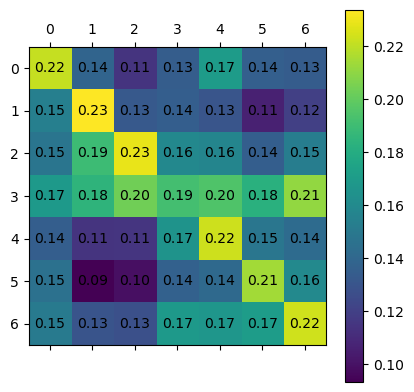

In [28]:
# get cosine similarity matrix on THuman-0000
test_name = '0000'
view_idx = 4
out_root = '/home/keito/Documents/ECCV2024_Post/zero_shot_gpt/outputs1/{}'.format(test_name)
view_dir = os.path.join(out_root, 'view_{}'.format(view_idx))
img_path = out_root + '/img_{}.png'.format(view_idx)

image = Image.open(img_path).convert('RGB')
image = preprocess(image).unsqueeze(0).half().to(device)

mask_dict = {
    1: 'a photo of a person',
    5: 'a photo of a arm',
    7: 'a photo of a t-shirt',
    8: 'a photo of a hair',
    9: 'a photo of a face',
    12: 'a photo of shoes',
    13: 'a photo of a watch', # or wristband
    14: 'a photo of a pants'
}
# mask_dict = {
#     1: 'a person',
#     5: 'an arm',
#     7: 'a t-shirt',
#     8: 'hair',
#     9: 'a face',
#     12: 'shoes',
#     13: 'a watch', # or wristband
#     14: 'pants'
# }
mask_indices = [7, 14, 12, 13, 5, 9, 8]
text_list = [mask_dict[idx] for idx in mask_indices]
print(text_list)

text = alpha_clip.tokenize(text_list).to(device)
with torch.no_grad():
    text_features = model.encode_text(text)

mask_features_list = []
for mask_idx in mask_indices:
    mask_path = os.path.join(view_dir, 'mask_{:02d}.png'.format(mask_idx))
    mask = np.array(Image.open(mask_path))
    if len(mask.shape) == 2: binary_mask = (mask == 255)
    if len(mask.shape) == 3: binary_mask = (mask[:, :, 0] == 255)
    alpha = mask_transform((binary_mask * 255).astype(np.uint8))
    alpha = alpha.half().cuda().unsqueeze(dim=0)
    with torch.no_grad():
        mask_feature = model.visual(image, alpha)
    mask_features_list.append(mask_feature)


mask_features = torch.cat(mask_features_list, dim=0)

similarity_matrix = cosine_similarity(mask_features, text_features)
# similarity = (100.0 * similarity_matrix).softmax(dim=-1) # apply softmax for more discriminative classification
# similarity = similarity.cpu().numpy()
# plot_similarity_matrix(similarity)
similarity_matrix = similarity_matrix.cpu().numpy()
plot_similarity_matrix(similarity_matrix)


['a photo of a jacket', 'a photo of pants', 'a photo of shoes', 'a photo of glasses', 'a photo of a face', 'a photo of a hair', 'a photo of a right hand']


<Figure size 640x480 with 0 Axes>

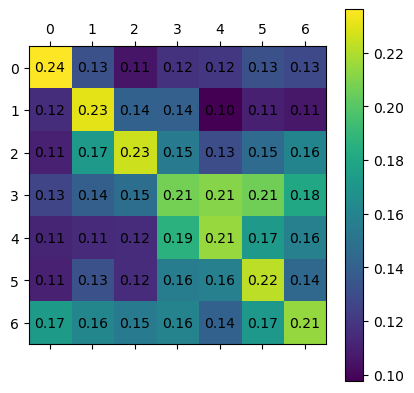

In [29]:
test_name = 'f_c_14238682637'
view_idx = 4
out_root = '/home/keito/Documents/ECCV2024_Post/zero_shot_gpt/outputs1/{}'.format(test_name)
view_dir = os.path.join(out_root, 'view_{}'.format(view_idx))
img_path = out_root + '/img_{}.png'.format(view_idx)

image = Image.open(img_path).convert('RGB')
image = preprocess(image).unsqueeze(0).half().to(device)

mask_dict = {
    1: 'a photo of shoes',
    2: 'a photo of a jacket',
    3: 'a photo of glasses',
    4: 'a photo of a hair',
    5: 'a photo of a face',
    8: 'a photo of pants',
    13: 'a photo of a right hand'
}
# mask_dict = {
#     1: 'shoes',
#     2: 'a jacket',
#     3: 'glasses',
#     4: 'hair',
#     5: 'a face',
#     8: 'pants',
#     13: 'right hand'
# }
mask_indices = [2, 8, 1, 3, 5, 4, 13]
text_list = [mask_dict[idx] for idx in mask_indices]
print(text_list)

text = alpha_clip.tokenize(text_list).to(device)
with torch.no_grad():
    text_features = model.encode_text(text)

mask_features_list = []
for mask_idx in mask_indices:
    mask_path = os.path.join(view_dir, 'mask_{:02d}.png'.format(mask_idx))
    mask = np.array(Image.open(mask_path))
    if len(mask.shape) == 2: binary_mask = (mask == 255)
    if len(mask.shape) == 3: binary_mask = (mask[:, :, 0] == 255)
    alpha = mask_transform((binary_mask * 255).astype(np.uint8))
    alpha = alpha.half().cuda().unsqueeze(dim=0)
    with torch.no_grad():
        mask_feature = model.visual(image, alpha)
    mask_features_list.append(mask_feature)


mask_features = torch.cat(mask_features_list, dim=0)

similarity_matrix = cosine_similarity(mask_features, text_features)
# similarity = (100.0 * similarity_matrix).softmax(dim=-1) # apply softmax for more discriminative classification
# similarity = similarity.cpu().numpy()
# plot_similarity_matrix(similarity)
similarity_matrix = similarity_matrix.cpu().numpy()
plot_similarity_matrix(similarity_matrix)

['a photo of a coat', 'a photo of a shirt', 'a photo of a face', 'a photo of hair', 'a photo of a left hand', 'a photo of a right hand', 'a photo of left shoe']


<Figure size 640x480 with 0 Axes>

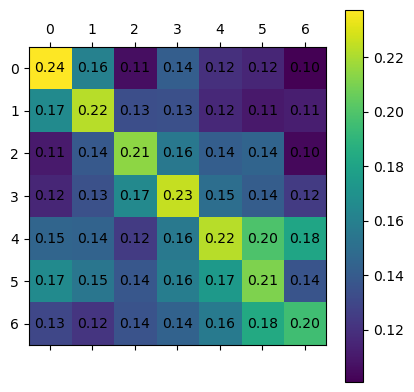

In [30]:
test_name = '0006'
view_idx = 2
out_root = '/home/keito/Documents/ECCV2024_Post/zero_shot_gpt/outputs1/{}'.format(test_name)
view_dir = os.path.join(out_root, 'view_{}'.format(view_idx))
img_path = out_root + '/img_{}.png'.format(view_idx)

image = Image.open(img_path).convert('RGB')
image = preprocess(image).unsqueeze(0).half().to(device)

# mask_dict = {
#     3: 'a coat',
#     5: 'a face',
#     7: 'a shirt',
#     8: 'left hand',
#     9: 'hair',
#     13: 'left shoe',
#     14: 'right hand',
#     15: 'right shoe'
# }
mask_dict = {
    3: 'a photo of a coat',
    5: 'a photo of a face',
    7: 'a photo of a shirt',
    8: 'a photo of a left hand',
    9: 'a photo of hair',
    13: 'a photo of left shoe',
    14: 'a photo of a right hand',
    15: 'a photo of a right shoe'
}
mask_indices = [3, 7, 5, 9, 8, 14, 13]
text_list = [mask_dict[idx] for idx in mask_indices]
print(text_list)

text = alpha_clip.tokenize(text_list).to(device)
with torch.no_grad():
    text_features = model.encode_text(text)

mask_features_list = []
for mask_idx in mask_indices:
    mask_path = os.path.join(view_dir, 'mask_{:02d}.png'.format(mask_idx))
    mask = np.array(Image.open(mask_path))
    if len(mask.shape) == 2: binary_mask = (mask == 255)
    if len(mask.shape) == 3: binary_mask = (mask[:, :, 0] == 255)
    alpha = mask_transform((binary_mask * 255).astype(np.uint8))
    alpha = alpha.half().cuda().unsqueeze(dim=0)
    with torch.no_grad():
        mask_feature = model.visual(image, alpha)
    mask_features_list.append(mask_feature)


mask_features = torch.cat(mask_features_list, dim=0)

similarity_matrix = cosine_similarity(mask_features, text_features)
# similarity = (100.0 * similarity_matrix).softmax(dim=-1) # apply softmax for more discriminative classification
# similarity = similarity.cpu().numpy()
# plot_similarity_matrix(similarity)
similarity_matrix = similarity_matrix.cpu().numpy()
plot_similarity_matrix(similarity_matrix)